In [3]:
import cv2
import numpy as np
from ultralytics import YOLO
import easyocr
import re # regex
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 2050


In [4]:
model = YOLO("license_plate\\license_plate_best.pt")
reader = easyocr.Reader(['en'], gpu = True)

In [5]:
# Regex: sau khi chuẩn hóa sẽ là 8 ký tự bất kỳ trong [A-Z0-9]
plate_pattern = re.compile(r"^[0-9A-Z]{8}$")

def correct_plate_format(ocr_text):
    # Upper + bỏ khoảng trắng, gạch, chấm
    ocr_text = ocr_text.upper()
    ocr_text = re.sub(r"[^A-Z0-9]", "", ocr_text)  # chỉ giữ A-Z, 0-9

    if len(ocr_text) != 8:
        return ""

    # Map lỗi OCR hay gặp
    map_to_letter = {"0":"O", "1":"I", "5":"S", "8":"B", "6":"G", "2":"Z"}
    map_to_digit  = {"O":"0", "I":"1", "Z":"2", "S":"5", "B":"8", "G":"6", "T":"7"}

    chars = list(ocr_text)

    # 0–1, 3–7 phải là số
    for i in [0, 1, 3, 4, 5, 6, 7]:
        ch = chars[i]
        if ch.isalpha():
            chars[i] = map_to_digit.get(ch, ch)

    # 2 phải là chữ
    ch = chars[2]
    if ch.isdigit():
        chars[2] = map_to_letter.get(ch, ch)

    candidate = "".join(chars)
    if plate_pattern.match(candidate):
        return candidate
    return ""


In [6]:
def debug_plate_pipeline(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Không đọc được ảnh!")
        return

    h, w = img.shape[:2]

    # 1) YOLO detect
    results = model(img, verbose=False)
    r = results[0]

    if len(r.boxes) == 0:
        print("Không có bbox biển số nào.")
        return

    # Lấy box có confidence cao nhất
    best_box = None
    best_conf = 0
    for box in r.boxes:
        conf = float(box.conf[0])
        if conf > best_conf:
            best_conf = conf
            best_box = box

    x1, y1, x2, y2 = map(int, best_box.xyxy.cpu().numpy()[0])

    # Clamp
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(w, x2); y2 = min(h, y2)

    plate_crop = img[y1:y2, x1:x2].copy()

    # 2) Tiền xử lý cho OCR
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    # lọc nhiễu nhẹ
    gray_blur = cv2.bilateralFilter(gray, 11, 17, 17)
    # threshold OTSU
    _, thresh = cv2.threshold(
        gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    # phóng to
    resized = cv2.resize(thresh, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # 3) OCR
    ocr_text = reader.readtext(
        resized, detail=0,
        allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    )
    print("OCR raw:", ocr_text)

    plate_final = ""
    if len(ocr_text) > 0:
        plate_final = correct_plate_format(ocr_text[0])
        print("Sau chuẩn hoá:", plate_final if plate_final else "(rỗng)")

    # 4) Vẽ lại bbox + text lên ảnh gốc
    annotated = img.copy()
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)
    if plate_final:
        cv2.putText(
            annotated, plate_final, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3
        )

    # 5) Hiển thị từng bước bằng matplotlib
    plt.figure(figsize=(15, 8))

    # Ảnh gốc
    plt.subplot(2, 3, 1)
    plt.title("Ảnh gốc")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # Ảnh YOLO annotated
    plt.subplot(2, 3, 2)
    plt.title("YOLO detect")
    yolo_vis = r.plot()  # vẽ bbox lên ảnh
    plt.imshow(cv2.cvtColor(yolo_vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # Crop biển số
    plt.subplot(2, 3, 3)
    plt.title("Crop biển số")
    plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # Gray
    plt.subplot(2, 3, 4)
    plt.title("Gray + lọc nhiễu")
    plt.imshow(gray_blur, cmap="gray")
    plt.axis("off")

    # Threshold
    plt.subplot(2, 3, 5)
    plt.title("Threshold (OTSU)")
    plt.imshow(thresh, cmap="gray")
    plt.axis("off")

    # Resized cho OCR
    plt.subplot(2, 3, 6)
    plt.title("Phóng to cho OCR")
    plt.imshow(resized, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


OCR raw: ['LBA028664']
Sau chuẩn hoá: (rỗng)


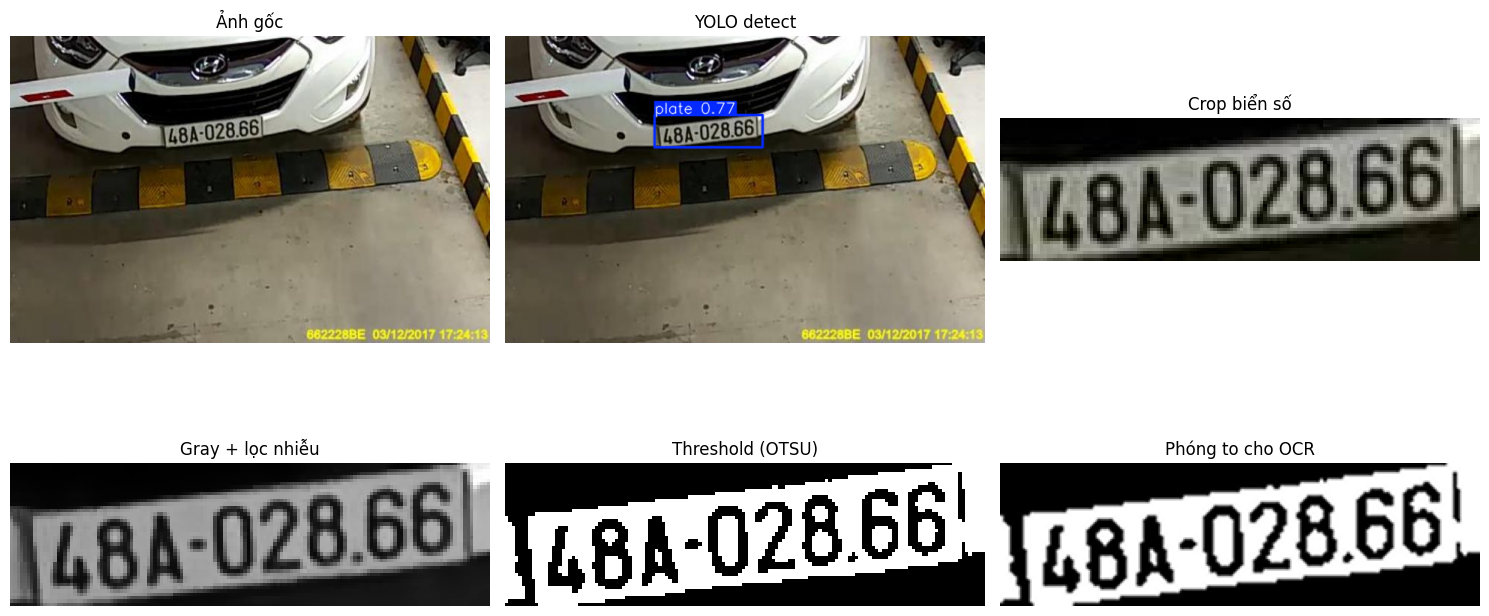

In [8]:
img_path = r"E:\HCMUTE\Nam3_dot2\Xulianhso\Nhap\data\images\Car113.jpg"
debug_plate_pipeline(img_path)


In [ ]:
# lấy ảnh kết quả từ YOLO
results = model(img_path)
res_img = results[0].plot()  # ảnh BGR

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()